#Task1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

dataset = pd.read_csv(r"C:\Users\3TEE\Downloads\students_dataset.csv")
dataset.head(3)
dataset.info()
dataset.describe()
dataset.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   30 non-null     int64  
 1   Name        30 non-null     object 
 2   Age         30 non-null     int64  
 3   Gender      30 non-null     object 
 4   City        30 non-null     object 
 5   Marks       29 non-null     float64
 6   Grade       30 non-null     object 
 7   Attendance  29 non-null     float64
 8   Passed      30 non-null     object 
dtypes: float64(2), int64(2), object(5)
memory usage: 2.2+ KB


StudentID     0
Name          0
Age           0
Gender        0
City          0
Marks         1
Grade         0
Attendance    1
Passed        0
dtype: int64

#Task 2

In [2]:
print(dataset.duplicated().sum())

0


In [3]:
dataset["Marks"].fillna(dataset["Marks"].median(), inplace=True)
dataset["Attendance"].fillna(dataset["Attendance"].mean(), inplace=True)
dataset["Attendance"] = dataset["Attendance"].astype(int)

dataset["Result"] = dataset["Marks"].apply(lambda x: "Pass" if x >=50 else "Fail")
dataset.isnull().sum()
dataset.head()

,StudentID,Name,Age,Gender,City,Marks,Grade,Attendance,Passed,Result
0,1,Ali Hassan,20,Male,Karachi,85.0,A,92,Yes,Pass
1,2,Sara Khan,22,Female,Lahore,73.0,B,88,Yes,Pass
2,3,Usman Ahmed,19,Male,Islamabad,91.0,A,95,Yes,Pass
3,4,Fatima Noor,21,Female,Karachi,60.0,C,76,Yes,Pass
4,5,Bilal Raza,23,Male,Peshawar,45.0,F,55,No,Fail


#Task 3

In [4]:
f"{dataset['Marks'].mean():.2f}"
f"{dataset['Marks'].max():.2f}"
f"{dataset['Marks'].min():.2f}"
f"{dataset['Marks'].std():.2f}"

'17.21'

In [5]:
dataset["Result"].value_counts()

Result
Pass    25
Fail     5
Name: count, dtype: int64

In [6]:
dataset.groupby("Gender")["Marks"].mean().round(2)

Gender
Female    72.60
Male      66.33
Name: Marks, dtype: float64

In [7]:
dataset.groupby("City")["Marks"].mean().round(2)

City
Islamabad    67.50
Karachi      70.90
Lahore       77.75
Peshawar     55.67
Quetta       60.33
Name: Marks, dtype: float64

In [8]:
dataset["Grade"].value_counts()

Grade
A    9
B    8
C    5
F    5
D    3
Name: count, dtype: int64

In [9]:
Q1 = dataset["Marks"].quantile(0.25)
Q3 = dataset["Marks"].quantile(0.75)
IQR = Q3 - Q1
outliers = dataset[(dataset["Marks"] < Q1 - 1.5*IQR) | dataset["Marks"] > Q3 + 1.5*IQR]
print(outliers)

Empty DataFrame
Columns: [StudentID, Name, Age, Gender, City, Marks, Grade, Attendance, Passed, Result]
Index: []


In [10]:
corr = dataset["Marks"].corr(dataset["Attendance"])*100
print(corr)

98.18542422271322


#Task4 Visualization

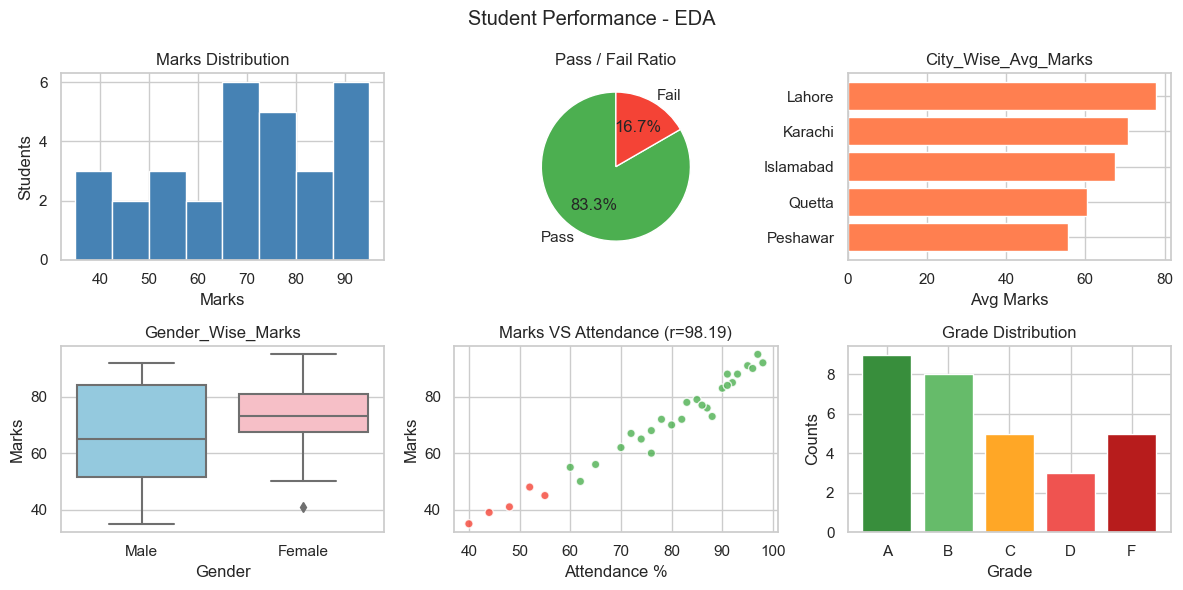

In [11]:
sns.set_theme(style = "whitegrid")
fig, axes = plt.subplots(2, 3, figsize = (12, 6))
fig.suptitle("Student Performance - EDA")

axes[0,0].hist(dataset["Marks"], bins=8, color= "steelblue", edgecolor= "white")
axes[0,0].set_title("Marks Distribution")
axes[0,0].set_xlabel("Marks")
axes[0,0].set_ylabel("Students")

counts = dataset["Result"].value_counts()
axes[0,1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90, wedgeprops={'edgecolor':'white'})
axes[0,1].set_title("Pass / Fail Ratio")

city_avg = dataset.groupby("City")["Marks"].mean().sort_values()
axes[0,2].barh(city_avg.index, city_avg.values, color= 'coral', edgecolor= 'white')
axes[0,2].set_title("City_Wise_Avg_Marks")
axes[0,2].set_xlabel("Avg Marks")

sns.boxplot(x="Gender", y= "Marks", data=dataset, ax=axes[1,0], palette= {'Male':'skyblue', 'Female':'lightpink'})
axes[1,0].set_title("Gender_Wise_Marks")

colors= dataset["Result"].map({'Pass':'#4CAF50', 'Fail':'#F44336'}).fillna('#F44336')
axes[1,1].scatter(dataset['Attendance'], dataset['Marks'], c=colors, alpha=0.8, edgecolor='white')
axes[1,1].set_title(f"Marks VS Attendance (r={corr:.2f})")
axes[1,1].set_xlabel("Attendance %")
axes[1,1].set_ylabel("Marks")

grade_order = ['A','B','C','D','F']
grade_counts = dataset["Grade"].value_counts().reindex(grade_order)
axes[1,2].bar(grade_counts.index, grade_counts.values, color=['#388E3C', '#66BB6A', '#FFA726', '#EF5350', '#B71C1C'], edgecolor='white')
axes[1,2].set_title("Grade Distribution")
axes[1,2].set_xlabel("Grade")
axes[1,2].set_ylabel("Counts")
plt.tight_layout()
plt.show()

In [12]:
x= dataset.iloc[:, :-1]
y= dataset["Result"]

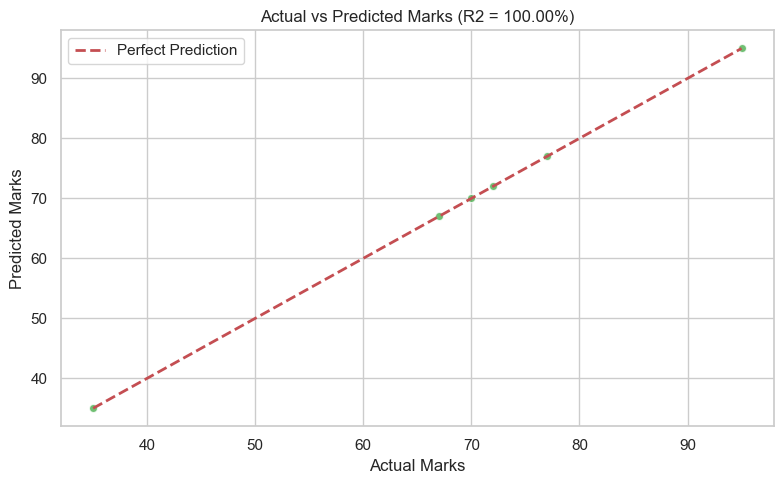

In [13]:
x = dataset[['Attendance', 'Marks']]
y = dataset['Marks']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test) * 100

y_pred = lr.predict(x_test)  

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='#4CAF50', edgecolor='white', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f"Actual vs Predicted Marks (R2 = {lr.score(x_test, y_test)*100:.2f}%)")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.legend()
plt.tight_layout()
plt.show()